In [1]:
import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from joblib import parallel_backend
from scipy.stats import mstats
from sklearn.decomposition import PCA


In [2]:
root_dir = r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/'

In [3]:
df = pd.read_csv(root_dir + 'Data/Silver/Silver_1.csv')
print(df.columns)


Index(['Country_Code', 'Year', 'Partner_Name', 'standard_name',
       'AHS_Weighted_Average_Percent', 'MFN_Weighted_Average_Percent',
       'AHS_Duty_Free_Tariff_Lines_Share_Percent', 'has_RCA',
       'has_Country_Growth', 'cc_rank', 'pv_rank', 'rl_rank', 'va_rank',
       'Log_Export', 'Log_Import', 'Tariff_Gap', 'Country_Growth_Percent'],
      dtype='object')


In [4]:
df.drop(columns=['Partner_Name'], inplace=True)
df.rename(columns={'standard_name': 'Country_Name'}, inplace=True)

In [5]:
df.describe()

,Year,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent
count,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000,5623.00000,5540.000000,5571.000000,5614.000000,5595.000000,5623.000000,5623.000000,5623.000000,4126.000000
mean,2009.857194,4.979779,9.338014,57.236084,0.755646,0.73395,46.154386,44.760959,45.529925,45.547828,16.154083,15.624336,4.358234,4.289981
std,7.002062,4.522902,4.708389,18.812375,0.429741,0.44193,29.233939,28.669390,29.674160,29.478824,2.746895,3.093200,4.111100,10.411500
min,1996.000000,0.000000,1.770000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322083,-31.940000,-62.280000
25%,2004.000000,1.790000,6.200000,41.990000,1.000000,0.00000,19.000000,19.600000,18.800000,19.200000,14.435726,13.609598,2.050000,-1.325000
50%,2010.000000,4.160000,8.490000,58.930000,1.000000,1.00000,44.300000,42.000000,45.000000,43.500000,16.102132,15.596026,3.570000,4.245000
75%,2016.000000,6.760000,11.610000,72.355000,1.000000,1.00000,69.900000,68.400000,68.600000,70.000000,18.027325,18.010012,6.140000,9.810000
max,2021.000000,52.210000,49.080000,100.000000,1.000000,1.00000,100.000000,100.000000,100.000000,100.000000,22.908755,22.803758,39.050000,174.000000


In [6]:
df.shape

(5623, 16)

In [7]:
df.isnull().sum()

Country_Code                                   0
Year                                           0
Country_Name                                   0
AHS_Weighted_Average_Percent                   0
MFN_Weighted_Average_Percent                   0
AHS_Duty_Free_Tariff_Lines_Share_Percent       0
has_RCA                                        0
has_Country_Growth                             0
cc_rank                                       83
pv_rank                                       52
rl_rank                                        9
va_rank                                       28
Log_Export                                     0
Log_Import                                     0
Tariff_Gap                                     0
Country_Growth_Percent                      1497
dtype: int64

## Điền missing value cho Country_Growth_Percent

- Country_Growth_Percent missing 1497/5623(27%) 
- Không thể chỉ sử dụng has_Country_Growth bởi vì không phản ánh đúng quy mô của nền kinh tế
- Không thể điền mean hay median vì đây là MNAR bởi vì Country_Growth_Percentage phụ thuộc vào tổng kim ngạch của năm nay so với năm trước đó
  
-> Sử dụng predictive imputation bằng KNN với n_neighbors = 3

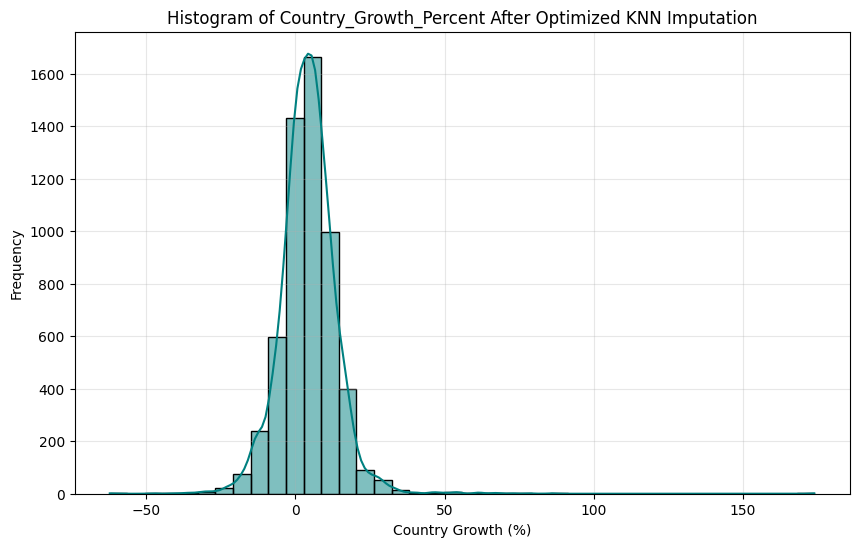


Thống kê sau imputation:
count    5623.000000
mean        4.279234
std         9.561809
min       -62.280000
25%        -0.885000
50%         4.193333
75%         9.430000
max       174.000000
Name: Country_Growth_Percent, dtype: float64


In [8]:
reduced_features = [
    'Log_Export',
    'Log_Import',
    'Tariff_Gap',
    'Year',
    'Country_Growth_Percent'
]

df_impute = df[reduced_features].copy()


scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_impute), columns=reduced_features)


imputer = KNNImputer(n_neighbors=3)

with parallel_backend('loky', n_jobs=-1):
    df_imputed_scaled = pd.DataFrame(
        imputer.fit_transform(df_scaled),
        columns=reduced_features
    )

df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    columns=reduced_features
)

df['Country_Growth_Percent'] = df_imputed['Country_Growth_Percent']

plt.figure(figsize=(10, 6))
sns.histplot(df['Country_Growth_Percent'], bins=40, kde=True, color='teal')
plt.title('Histogram of Country_Growth_Percent After Optimized KNN Imputation')
plt.xlabel('Country Growth (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print("\nThống kê sau imputation:")
print(df['Country_Growth_Percent'].describe())

In [9]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5623 entries, 0 to 5622
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country_Code                              5623 non-null   object 
 1   Year                                      5623 non-null   int64  
 2   Country_Name                              5623 non-null   object 
 3   AHS_Weighted_Average_Percent              5623 non-null   float64
 4   MFN_Weighted_Average_Percent              5623 non-null   float64
 5   AHS_Duty_Free_Tariff_Lines_Share_Percent  5623 non-null   float64
 6   has_RCA                                   5623 non-null   int64  
 7   has_Country_Growth                        5623 non-null   int64  
 8   cc_rank                                   5540 non-null   float64
 9   pv_rank                                   5571 non-null   float64
 10  rl_rank                             

In [10]:
print(df.describe())

              Year  AHS_Weighted_Average_Percent  \
count  5623.000000                   5623.000000   
mean   2009.857194                      4.979779   
std       7.002062                      4.522902   
min    1996.000000                      0.000000   
25%    2004.000000                      1.790000   
50%    2010.000000                      4.160000   
75%    2016.000000                      6.760000   
max    2021.000000                     52.210000   

       MFN_Weighted_Average_Percent  AHS_Duty_Free_Tariff_Lines_Share_Percent  \
count                   5623.000000                               5623.000000   
mean                       9.338014                                 57.236084   
std                        4.708389                                 18.812375   
min                        1.770000                                  0.000000   
25%                        6.200000                                 41.990000   
50%                        8.490000          

clip Tariff_Gap phần âm bởi vì thông thường MFN sẽ cao hơn AHS , chỉ trong 1 số trường hợp đặt biệt được pháp luật cho phép và không vượt qua mức bounded tariff như chống bán phá giá, bảo vệ hàng nội địa

In [11]:
df['Tariff_Gap'] = df['Tariff_Gap'].clip(lower=0)

df['Country_Growth_Percent'] = mstats.winsorize(
    df['Country_Growth_Percent'], 
    limits=[0.01, 0.01]  
)

In [12]:
df.drop(columns = ['has_Country_Growth'], inplace=True)

In [13]:
df['Effective_Tariff'] = df['AHS_Weighted_Average_Percent'] * (
    1 - df['AHS_Duty_Free_Tariff_Lines_Share_Percent'] / 100
)

In [14]:
df.describe()

,Year,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
count,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000,5540.000000,5571.000000,5614.000000,5595.000000,5623.000000,5623.000000,5623.000000,5623.000000,5623.000000
mean,2009.857194,4.979779,9.338014,57.236084,0.755646,46.154386,44.760959,45.529925,45.547828,16.154083,15.624336,4.526278,4.204350,2.410284
std,7.002062,4.522902,4.708389,18.812375,0.429741,29.233939,28.669390,29.674160,29.478824,2.746895,3.093200,3.664245,8.557513,2.619153
min,1996.000000,0.000000,1.770000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322083,0.000000,-18.200000,0.000000
25%,2004.000000,1.790000,6.200000,41.990000,1.000000,19.000000,19.600000,18.800000,19.200000,14.435726,13.609598,2.050000,-0.885000,0.504164
50%,2010.000000,4.160000,8.490000,58.930000,1.000000,44.300000,42.000000,45.000000,43.500000,16.102132,15.596026,3.570000,4.193333,1.582347
75%,2016.000000,6.760000,11.610000,72.355000,1.000000,69.900000,68.400000,68.600000,70.000000,18.027325,18.010012,6.140000,9.430000,3.484544
max,2021.000000,52.210000,49.080000,100.000000,1.000000,100.000000,100.000000,100.000000,100.000000,22.908755,22.803758,39.050000,29.160000,24.879465


In [15]:
df.isna().sum()

Country_Code                                 0
Year                                         0
Country_Name                                 0
AHS_Weighted_Average_Percent                 0
MFN_Weighted_Average_Percent                 0
AHS_Duty_Free_Tariff_Lines_Share_Percent     0
has_RCA                                      0
cc_rank                                     83
pv_rank                                     52
rl_rank                                      9
va_rank                                     28
Log_Export                                   0
Log_Import                                   0
Tariff_Gap                                   0
Country_Growth_Percent                       0
Effective_Tariff                             0
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.drop(columns=['cc_rank','rl_rank', 'Log_Import'], inplace=True)

drop do corr quá cao -> multicollinearity , giữ lại Log_Import vì đây là động lực chính của thương mại quốc tế

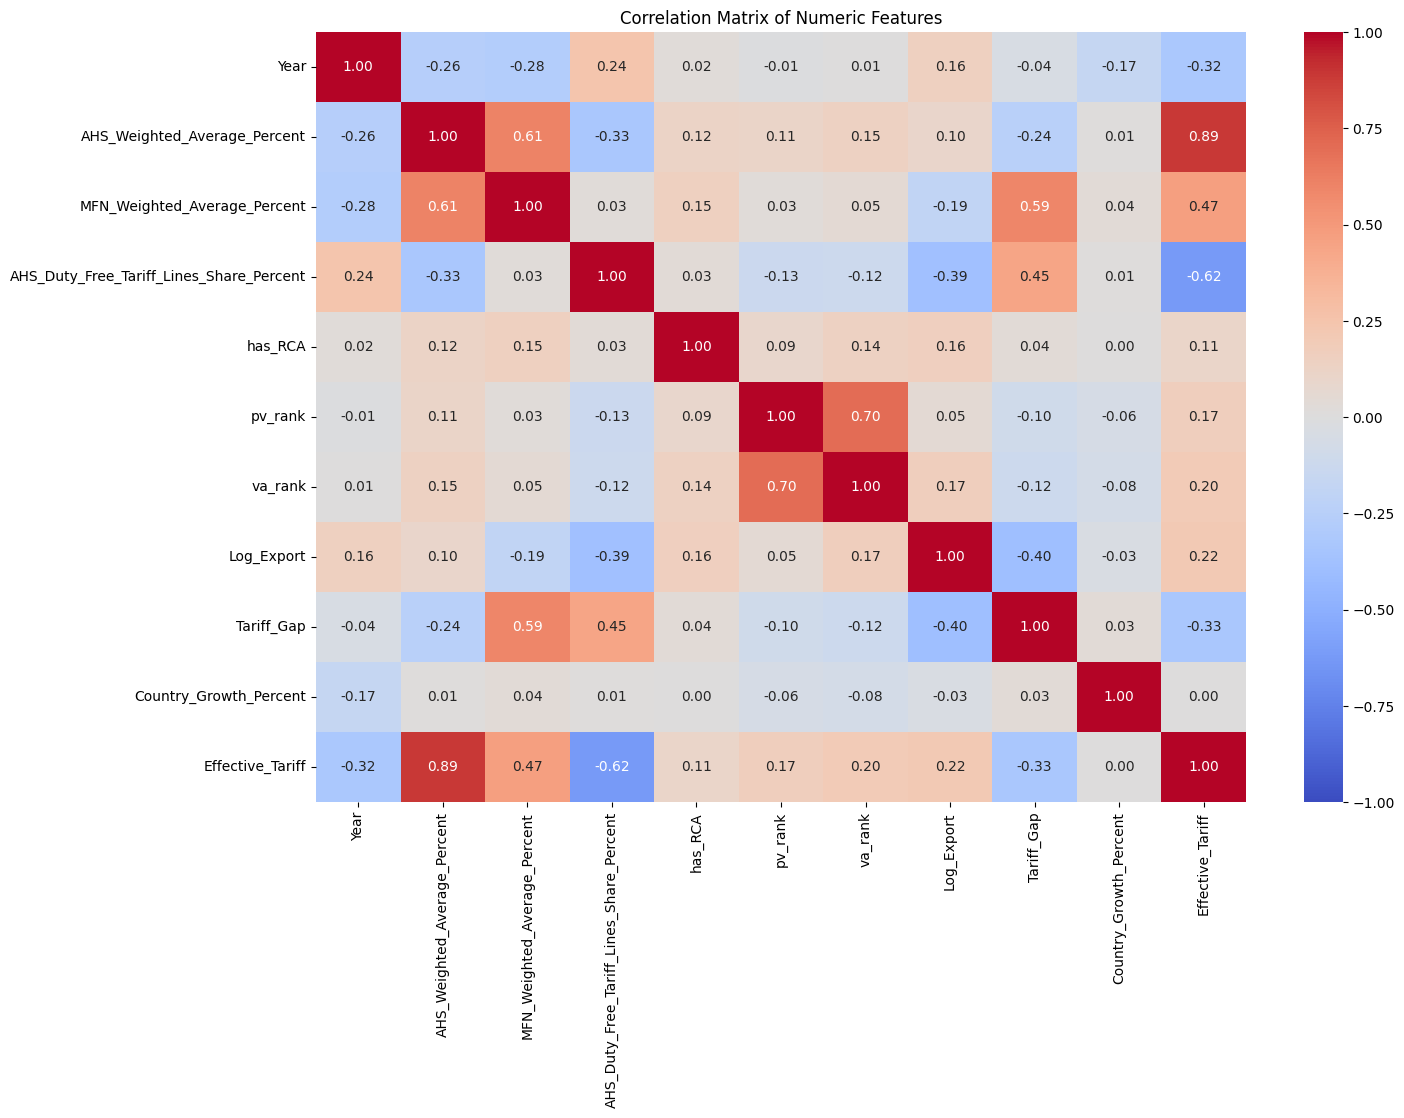

In [18]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [19]:
df.to_csv(r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/Data/Gold/Gold_1.csv', index=False,encoding='utf-8-sig')

In [20]:
df.head()

,Country_Code,Year,Country_Name,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,pv_rank,va_rank,Log_Export,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
0,ABW,2004,Aruba,3.31,5.69,56.76,1,80.6,73.1,14.770925,2.38,1.73,1.431244
1,ABW,2005,Aruba,2.22,5.78,47.31,1,96.1,85.6,14.960064,3.56,8.43,1.169718
2,ABW,2006,Aruba,2.76,6.11,39.90,1,96.1,80.3,15.051433,3.35,0.55,1.658760
3,ABW,2007,Aruba,2.39,5.91,52.70,1,96.6,78.4,14.917213,3.52,3.42,1.130470
4,ABW,2008,Aruba,2.78,7.56,47.17,1,96.2,79.3,14.880180,4.78,-0.06,1.468674


In [21]:
df.shape

(5500, 13)

In [22]:
df.describe()

,Year,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,pv_rank,va_rank,Log_Export,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2009.930182,4.948271,9.291342,57.349465,0.765636,44.229182,45.003509,16.243094,4.499411,4.216481,2.388314
std,6.964608,4.453968,4.669661,18.689147,0.423639,28.447239,29.353273,2.693979,3.640979,8.591435,2.575885
min,1996.000000,0.000000,1.770000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-18.200000,0.000000
25%,2005.000000,1.790000,6.190000,42.167500,1.000000,19.300000,18.900000,14.553821,2.040000,-0.930000,0.502075
50%,2010.000000,4.155000,8.460000,59.025000,1.000000,41.250000,42.700000,16.164340,3.540000,4.220000,1.581417
75%,2016.000000,6.740000,11.570000,72.382500,1.000000,67.500000,69.000000,18.067678,6.092500,9.470833,3.474040
max,2021.000000,52.210000,49.080000,100.000000,1.000000,100.000000,100.000000,22.908755,39.050000,29.160000,24.879465


In [23]:
df.columns

Index(['Country_Code', 'Year', 'Country_Name', 'AHS_Weighted_Average_Percent',
       'MFN_Weighted_Average_Percent',
       'AHS_Duty_Free_Tariff_Lines_Share_Percent', 'has_RCA', 'pv_rank',
       'va_rank', 'Log_Export', 'Tariff_Gap', 'Country_Growth_Percent',
       'Effective_Tariff'],
      dtype='object')

(array([ 72.,  16.,  17.,  21.,  37.,  44.,  37.,  38.,  30.,  48.,  56.,
         95.,  90.,  81., 131., 149., 179., 180., 243., 253., 228., 252.,
        265., 272., 253., 291., 264., 231., 218., 192., 170., 191., 119.,
         98., 108.,  78.,  95.,  65.,  55.,  37.,  31.,  21.,  16.,  13.,
         12.,  16.,   5.,  16.,  10.,  61.]),
 array([-18.2   , -17.2528, -16.3056, -15.3584, -14.4112, -13.464 ,
        -12.5168, -11.5696, -10.6224,  -9.6752,  -8.728 ,  -7.7808,
         -6.8336,  -5.8864,  -4.9392,  -3.992 ,  -3.0448,  -2.0976,
         -1.1504,  -0.2032,   0.744 ,   1.6912,   2.6384,   3.5856,
          4.5328,   5.48  ,   6.4272,   7.3744,   8.3216,   9.2688,
         10.216 ,  11.1632,  12.1104,  13.0576,  14.0048,  14.952 ,
         15.8992,  16.8464,  17.7936,  18.7408,  19.688 ,  20.6352,
         21.5824,  22.5296,  23.4768,  24.424 ,  25.3712,  26.3184,
         27.2656,  28.2128,  29.16  ]),
 <BarContainer object of 50 artists>)

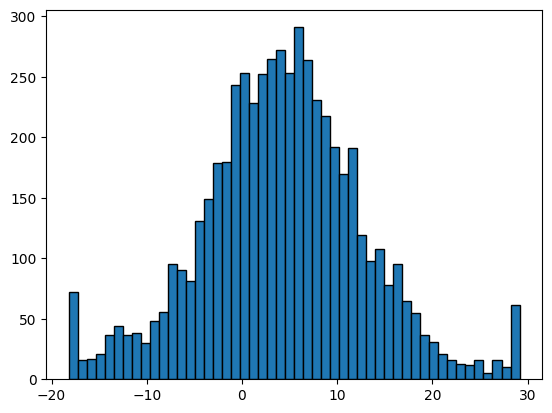

In [24]:
plt.hist(df['Country_Growth_Percent'], bins=50, edgecolor='black')